Epoch 1/5 | Loss: 0.6290
Epoch 2/5 | Loss: 0.2364
Epoch 3/5 | Loss: 0.0611
Epoch 4/5 | Loss: 0.0366
Epoch 5/5 | Loss: 0.0312

Test Accuracy: 93.44%
Saved: training_loss.png


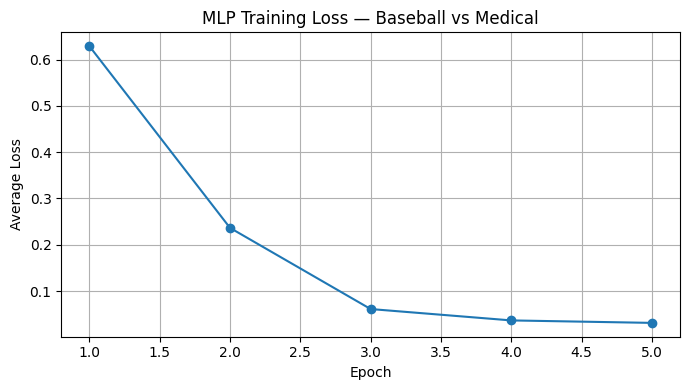

In [2]:
# Day B-4: PyTorch nn.Module + Training Loop
# Binary classification: baseball vs medical (20 Newsgroups)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

# 1. Load and prepare data
categories = ['rec.sport.baseball', 'sci.med']
train_data = fetch_20newsgroups(subset='train', categories=categories, remove=('headers','footers','quotes'))
test_data  = fetch_20newsgroups(subset='test',  categories=categories, remove=('headers','footers','quotes'))

vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(train_data.data).toarray()
X_test  = vectorizer.transform(test_data.data).toarray()
y_train = train_data.target.astype('float32')
y_test  = test_data.target.astype('float32')

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train).unsqueeze(1)   # shape: (N, 1)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test).unsqueeze(1)

dataset    = TensorDataset(X_train_t, y_train_t)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# 2. Define the model
class MLPClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)    # raw logit — BCEWithLogitsLoss handles sigmoid
        )

    def forward(self, x):
        return self.net(x)

model     = MLPClassifier(input_dim=5000)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 3. Training loop
n_epochs = 5
epoch_losses = []

for epoch in range(n_epochs):
    model.train()
    batch_losses = []
    for X_batch, y_batch in dataloader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss   = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    avg_loss = sum(batch_losses) / len(batch_losses)
    epoch_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{n_epochs} | Loss: {avg_loss:.4f}")

# 4. Evaluate on test set
model.eval()
with torch.no_grad():
    logits = model(X_test_t)
    preds  = (torch.sigmoid(logits) > 0.5).float()
    acc    = (preds == y_test_t).float().mean().item()
print(f"\nTest Accuracy: {acc*100:.2f}%")

# 5. Plot training loss
plt.figure(figsize=(7, 4))
plt.plot(range(1, n_epochs+1), epoch_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("MLP Training Loss — Baseball vs Medical")
plt.grid(True)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=100)
print("Saved: training_loss.png")